# Preprocessing

### Outline
- Case Folding (Uppercase to Lowercase)
- Removing Noise (URLs, HTML tags, special characters, numbers)
- Tokenization
- Stopword Removal (before & after comparison)
- Lemmatization (root words / kata dasar)

## 1. Import Libraries & Load Data

In [2]:
# Install required libraries (run once)
!pip install pandas nltk sastrawi matplotlib seaborn wordcloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Indonesian stemmer (for Bahasa Indonesia articles if applicable)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Download NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

print('All libraries loaded successfully.')

KeyboardInterrupt: 

In [ ]:
df = pd.read_csv('dataset/dataset.csv')

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset loaded: 1001 rows, 4 columns
Columns: ['date', 'link', 'title', 'content']


,date,link,title,content
0,2025-01-21 8:00,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ..."
1,2025-01-21 8:00,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te..."
2,2025-01-22 8:00,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones..."
3,2025-03-04 8:00,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga..."
4,2025-03-19 7:00,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...


## 2. Initial Data Exploration

In [ ]:
df.columns = df.columns.str.strip().str.lower()

print('Column names after standardization:', list(df.columns))
print()
print(df.info())

Column names after standardization: ['date', 'link', 'title', 'content']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   date     1001 non-null   object
 1   link     1001 non-null   object
 2   title    1001 non-null   object
 3   content  1001 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB
None


In [ ]:
# Basic statistics
print('=== Dataset Overview ===')
print(f'Total articles     : {len(df)}')
print(f'Duplicate rows     : {df.duplicated().sum()}')
print(f'Missing values per column:')
print(df.isnull().sum())
print()

# Content length distribution
df['konten_length'] = df['content'].astype(str).apply(len)
df['konten_word_count'] = df['content'].astype(str).apply(lambda x: len(x.split()))

# Correct way to rename the 'content' column to 'konten'
df = df.rename(columns={'content': 'konten'})

print(f'Content length (characters) - min: {df["konten_length"].min()}, '
      f'max: {df["konten_length"].max()}, '
      f'mean: {df["konten_length"].mean():.0f}')
print(f'Content word count - min: {df["konten_word_count"].min()}, '
      f'max: {df["konten_word_count"].max()}, '
      f'mean: {df["konten_word_count"].mean():.0f}')

=== Dataset Overview ===
Total articles     : 1001
Duplicate rows     : 0
Missing values per column:
date                 0
link                 0
title                0
content              0
konten_length        0
konten_word_count    0
dtype: int64

Content length (characters) - min: 154, max: 26287, mean: 4307
Content word count - min: 20, max: 3601, mean: 581


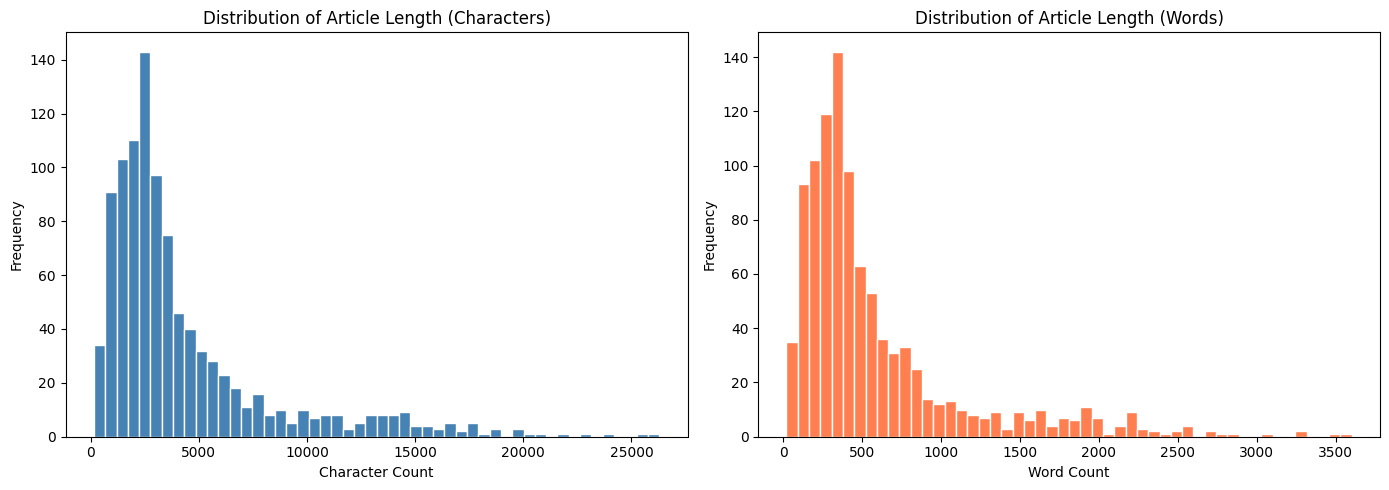

In [ ]:
# Visualize content length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['konten_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Article Length (Characters)')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['konten_word_count'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Article Length (Words)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 3. Data Cleaning

In [ ]:
# Remove duplicates
before_dedup = len(df)
df = df.drop_duplicates(subset=['konten'], keep='first').reset_index(drop=True)
after_dedup = len(df)
print(f'Removed {before_dedup - after_dedup} duplicate articles.')
print(f'Remaining articles: {after_dedup}')

Removed 2 duplicate articles.
Remaining articles: 999


In [ ]:
# Remove rows with missing or empty content

before_clean = len(df)
df = df.dropna(subset=['konten']).reset_index(drop=True)
df = df[df['konten'].astype(str).str.strip() != ''].reset_index(drop=True)
after_clean = len(df)
print(f'Removed {before_clean - after_clean} rows with empty/missing content.')
print(f'Remaining articles: {after_clean}')

Removed 0 rows with empty/missing content.
Remaining articles: 999


## 4. Text Preprocessing Pipeline

The preprocessing pipeline includes:
1. Case folding (uppercase to lowercase)
2. Noise removal (URLs, HTML tags, special characters, extra whitespace)
3. Tokenization
4. Stopword removal
5. Lemmatization

### 4.1 Case Folding (Uppercase to Lowercase)

In [ ]:
# Convert all text to lowercase
df['konten_clean'] = df['konten'].astype(str).str.lower()

print('Case folding completed.')
print('\nBefore (sample):')
print(df['konten'].iloc[0][:200])
print('\nAfter (sample):')
print(df['konten_clean'].iloc[0][:200])

Case folding completed.

Before (sample):
Jakarta, CNBC Indonesia -Amerika Serikat (AS) secara resmi memiliki Presiden baru yang disambut positif karena agenda pro-bisnis yang dibawanya.
Presiden Amerika Serikat (AS) Donald Trump resmi dilant

After (sample):
jakarta, cnbc indonesia -amerika serikat (as) secara resmi memiliki presiden baru yang disambut positif karena agenda pro-bisnis yang dibawanya.
presiden amerika serikat (as) donald trump resmi dilant


### 4.2 Noise Removal

In [ ]:
def remove_noise(text):
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove mentions
    text = re.sub(r'@\w+', ' ', text)

    # Remove hashtag symbol (keep the word)
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove special characters and punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove single characters (except 'a' and 'i' for English)
    text = re.sub(r'\b[b-hj-z]\b', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['konten_clean'] = df['konten_clean'].apply(remove_noise)

print('Noise removal completed.')
print('\nSample result:')
print(df['konten_clean'].iloc[0][:300])

Noise removal completed.

Sample result:
jakarta cnbc indonesia amerika serikat as secara resmi memiliki presiden baru yang disambut positif karena agenda pro bisnis yang dibawanya presiden amerika serikat as donald trump resmi dilantik pada senin waktu as secara umum dalam pidatonya trump mengungkapkan kebijakan perdagangan proteksionis y


### 4.3 Tokenization

In [ ]:
# Tokenize the cleaned text into individual words

df['tokens'] = df['konten_clean'].apply(word_tokenize)

print('Tokenization completed.')
print(f'\nSample tokens (first 20 tokens of first article):')
print(df['tokens'].iloc[0][:20])

Tokenization completed.

Sample tokens (first 20 tokens of first article):
['jakarta', 'cnbc', 'indonesia', 'amerika', 'serikat', 'as', 'secara', 'resmi', 'memiliki', 'presiden', 'baru', 'yang', 'disambut', 'positif', 'karena', 'agenda', 'pro', 'bisnis', 'yang', 'dibawanya']


In [ ]:
df['n_tokens_before_stopwords'] = df['tokens'].apply(len)

# Also store the text version before stopword removal
df['text_before_stopwords'] = df['tokens'].apply(lambda x: ' '.join(x))

print('Token counts before stopword removal:')
print(df['n_tokens_before_stopwords'].describe())

Token counts before stopword removal:
count     985.000000
mean      581.876142
std       547.011847
min        50.000000
25%       257.000000
50%       384.000000
75%       692.000000
max      3573.000000
Name: n_tokens_before_stopwords, dtype: float64


### 4.4 Stopword Removal

In [ ]:
# English stopwords
stop_words_en = set(stopwords.words('english'))

# Indonesian stopwords
stop_words_id = set(stopwords.words('indonesian'))

# Combine both
combined_stopwords = stop_words_en.union(stop_words_id)

# Add custom domain-specific stopwords
# (common words in news articles that do not carry meaning)
custom_stopwords = {
    'said', 'also', 'would', 'could', 'one', 'two', 'new',
    'like', 'get', 'make', 'may', 'us', 'year', 'years',
    'reuters', 'ap', 'afp', 'foto', 'baca', 'juga',
    'jakarta', 'kompas', 'detik', 'cnbc', 'cnn', 'bbc',
    'read', 'more', 'click', 'share', 'comment', 'subscribe'
}
combined_stopwords = combined_stopwords.union(custom_stopwords)

print(f'Total stopwords: {len(combined_stopwords)}')
print(f'  - English: {len(stop_words_en)}')
print(f'  - Indonesian: {len(stop_words_id)}')
print(f'  - Custom: {len(custom_stopwords)}')

Total stopwords: 985
  - English: 198
  - Indonesian: 757
  - Custom: 32


In [ ]:
# Apply stopword removal
df['tokens_no_stopwords'] = df['tokens'].apply(
    lambda tokens: [word for word in tokens if word not in combined_stopwords]
)

df['n_tokens_after_stopwords'] = df['tokens_no_stopwords'].apply(len)

# Text version after stopword removal
df['text_after_stopwords'] = df['tokens_no_stopwords'].apply(lambda x: ' '.join(x))

print('Stopword removal completed.')
print(f'\nAverage tokens BEFORE stopwords: {df["n_tokens_before_stopwords"].mean():.0f}')
print(f'Average tokens AFTER stopwords : {df["n_tokens_after_stopwords"].mean():.0f}')
print(f'Average reduction              : {((df["n_tokens_before_stopwords"].mean() - df["n_tokens_after_stopwords"].mean()) / df["n_tokens_before_stopwords"].mean() * 100):.1f}%')

Stopword removal completed.

Average tokens BEFORE stopwords: 582
Average tokens AFTER stopwords : 336
Average reduction              : 42.3%


In [ ]:
# COMPARISON: Before vs After Stopword Removal

print('=== Before vs After Stopword Removal (Sample Article #1) ===')
print()
print('BEFORE stopwords (first 30 tokens):')
print(df['tokens'].iloc[0][:30])
print(f'Total tokens: {df["n_tokens_before_stopwords"].iloc[0]}')
print()
print('AFTER stopwords (first 30 tokens):')
print(df['tokens_no_stopwords'].iloc[0][:30])
print(f'Total tokens: {df["n_tokens_after_stopwords"].iloc[0]}')

=== Before vs After Stopword Removal (Sample Article #1) ===

BEFORE stopwords (first 30 tokens):
['jakarta', 'cnbc', 'indonesia', 'amerika', 'serikat', 'as', 'secara', 'resmi', 'memiliki', 'presiden', 'baru', 'yang', 'disambut', 'positif', 'karena', 'agenda', 'pro', 'bisnis', 'yang', 'dibawanya', 'presiden', 'amerika', 'serikat', 'as', 'donald', 'trump', 'resmi', 'dilantik', 'pada', 'senin']
Total tokens: 1104

AFTER stopwords (first 30 tokens):
['indonesia', 'amerika', 'serikat', 'resmi', 'memiliki', 'presiden', 'disambut', 'positif', 'agenda', 'pro', 'bisnis', 'dibawanya', 'presiden', 'amerika', 'serikat', 'donald', 'trump', 'resmi', 'dilantik', 'senin', 'pidatonya', 'trump', 'kebijakan', 'perdagangan', 'proteksionis', 'dikhawatirkan', 'agresif', 'diterapkan', 'terukur', 'trump']
Total tokens: 595


### 4.5 Lemmatization

In [ ]:
factory = StemmerFactory()
stemmer_id = factory.create_stemmer() # Corrected method name

def stem_tokens_id(tokens):
    """Stem Indonesian tokens using Sastrawi."""
    return [stemmer_id.stem(token) for token in tokens]

df['tokens_lemmatized'] = df['tokens_no_stopwords'].apply(stem_tokens_id)

print('Lemmatization completed.')
print(f'\nSample: BEFORE lemmatization (first 15 tokens):')
print(df['tokens_no_stopwords'].iloc[0][:15])
print(f'\nSample: AFTER lemmatization (first 15 tokens):')
print(df['tokens_lemmatized'].iloc[0][:15])

Lemmatization completed.

Sample: BEFORE lemmatization (first 15 tokens):
['indonesia', 'amerika', 'serikat', 'resmi', 'memiliki', 'presiden', 'disambut', 'positif', 'agenda', 'pro', 'bisnis', 'dibawanya', 'presiden', 'amerika', 'serikat']

Sample: AFTER lemmatization (first 15 tokens):
['indonesia', 'amerika', 'serikat', 'resmi', 'milik', 'presiden', 'sambut', 'positif', 'agenda', 'pro', 'bisnis', 'bawa', 'presiden', 'amerika', 'serikat']


In [ ]:
# Create final clean text column from lemmatized tokens

df['konten_preprocessed'] = df['tokens_lemmatized'].apply(lambda x: ' '.join(x))

print('Final preprocessed text created.')
print('\nSample:')
print(df['konten_preprocessed'].iloc[0][:300])

Final preprocessed text created.

Sample:
indonesia amerika serikat resmi milik presiden sambut positif agenda pro bisnis bawa presiden amerika serikat donald trump resmi lantik senin pidato trump bijak dagang proteksionis khawatir agresif terap ukur trump bawa agenda ambisius liput reformasi dagang imigrasi mangkas pajak deregulasi bijak p


## 5. Word Count Statistics (Before & After Stopwords)

In [ ]:

comparison_df = df[['n_tokens_before_stopwords', 'n_tokens_after_stopwords']].describe()
comparison_df.columns = ['Before Stopwords', 'After Stopwords']
print(comparison_df.round(2))

       Before Stopwords  After Stopwords
count            985.00           985.00
mean             581.88           335.60
std              547.01           318.37
min               50.00            31.00
25%              257.00           143.00
50%              384.00           219.00
75%              692.00           394.00
max             3573.00          2032.00


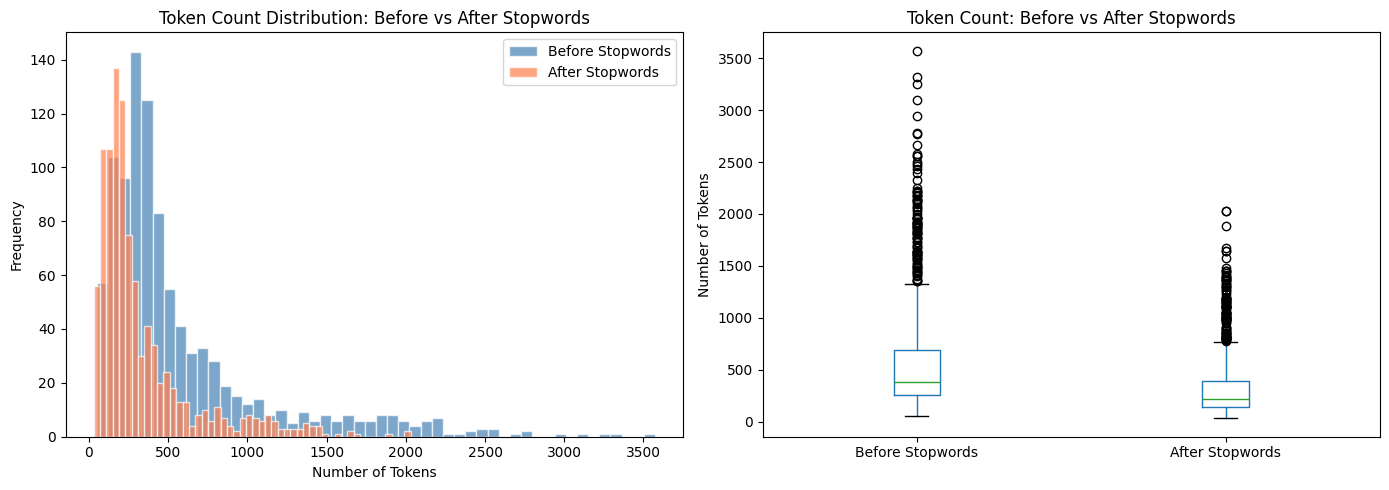

In [ ]:
# Visualization: Before vs After stopword removal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['n_tokens_before_stopwords'], bins=50, color='steelblue',
             edgecolor='white', alpha=0.7, label='Before Stopwords')
axes[0].hist(df['n_tokens_after_stopwords'], bins=50, color='coral',
             edgecolor='white', alpha=0.7, label='After Stopwords')
axes[0].set_title('Token Count Distribution: Before vs After Stopwords')
axes[0].set_xlabel('Number of Tokens')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot comparison
box_data = pd.DataFrame({
    'Before Stopwords': df['n_tokens_before_stopwords'],
    'After Stopwords': df['n_tokens_after_stopwords']
})
box_data.boxplot(ax=axes[1], grid=False)
axes[1].set_title('Token Count: Before vs After Stopwords')
axes[1].set_ylabel('Number of Tokens')

plt.tight_layout()
plt.show()

## 6. Top 100 Frequency Words

In [ ]:
all_tokens = [token for tokens_list in df['tokens_lemmatized'] for token in tokens_list]
word_freq = Counter(all_tokens)

# Top 100 words
top_100 = word_freq.most_common(100)

# Create a DataFrame for display
top_100_df = pd.DataFrame(top_100, columns=['Word', 'Frequency'])
top_100_df.index = top_100_df.index + 1  # Start index from 1
top_100_df.index.name = 'Rank'

print(f'Total unique words in corpus: {len(word_freq)}')
print(f'Total words in corpus: {len(all_tokens)}')
print()
print('=== Top 100 Most Frequent Words ===')
print(top_100_df.to_string())

Total unique words in corpus: 13487
Total words in corpus: 330566

=== Top 100 Most Frequent Words ===
               Word  Frequency
Rank                          
1             tarif      10158
2             trump       6284
3            negara       5904
4         indonesia       5298
5            dagang       5288
6             china       3808
7            persen       3445
8             impor       3284
9           ekonomi       3120
10            bijak       3094
11          amerika       2568
12           produk       2568
13            pasar       2430
14         perintah       2357
15           barang       2192
16         presiden       2071
17           ekspor       2059
18             laku       1990
19             kena       1866
20          serikat       1795
21            usaha       1778
22            harga       1726
23           global       1650
24           dampak       1631
25            turun       1630
26          tingkat       1629
27            dunia       126

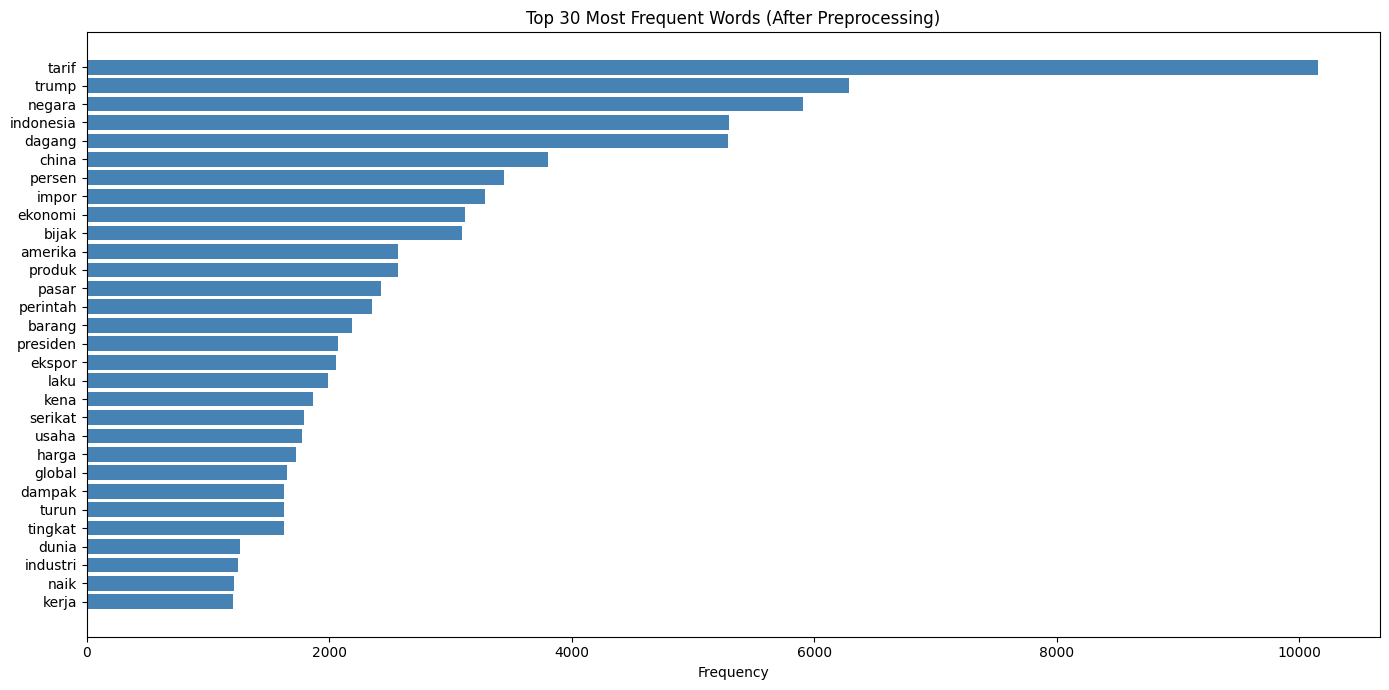

In [ ]:
# Visualization: Top 30 words bar chart

top_30 = top_100_df.head(30)

plt.figure(figsize=(14, 7))
plt.barh(range(len(top_30)), top_30['Frequency'].values, color='steelblue')
plt.yticks(range(len(top_30)), top_30['Word'].values)
plt.gca().invert_yaxis()
plt.xlabel('Frequency')
plt.title('Top 30 Most Frequent Words (After Preprocessing)')
plt.tight_layout()
plt.show()

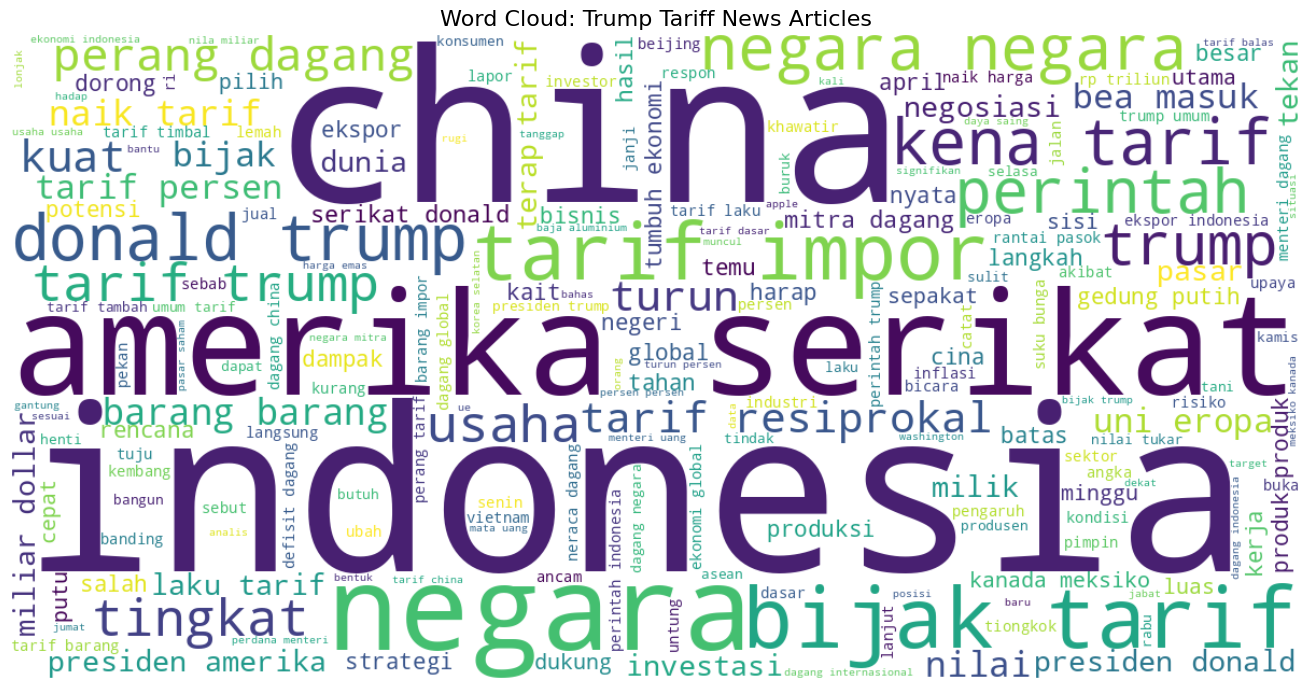

In [ ]:
# Word Cloud visualization

wordcloud_text = ' '.join(all_tokens)
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200,
    colormap='viridis',
    random_state=42
).generate(wordcloud_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Trump Tariff News Articles', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Export Preprocessed Dataset

In [ ]:
df

,date,link,title,konten,konten_length,konten_word_count,konten_clean,tokens,n_tokens_before_stopwords,text_before_stopwords,tokens_no_stopwords,n_tokens_after_stopwords,text_after_stopwords,tokens_lemmatized,konten_preprocessed
0,2025-01-21 8:00,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",8326,1108,jakarta cnbc indonesia amerika serikat as seca...,"[jakarta, cnbc, indonesia, amerika, serikat, a...",1104,jakarta cnbc indonesia amerika serikat as seca...,"[indonesia, amerika, serikat, resmi, memiliki,...",595,indonesia amerika serikat resmi memiliki presi...,"[indonesia, amerika, serikat, resmi, milik, pr...",indonesia amerika serikat resmi milik presiden...
1,2025-01-21 8:00,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",2925,399,jakarta cnbc indonesia nilai tukar rupiah terh...,"[jakarta, cnbc, indonesia, nilai, tukar, rupia...",387,jakarta cnbc indonesia nilai tukar rupiah terh...,"[indonesia, nilai, tukar, rupiah, dolar, ameri...",217,indonesia nilai tukar rupiah dolar amerika ser...,"[indonesia, nilai, tukar, rupiah, dolar, ameri...",indonesia nilai tukar rupiah dolar amerika ser...
2,2025-01-22 8:00,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",13102,1747,jakarta cnbc indonesia pasar keuangan indonesi...,"[jakarta, cnbc, indonesia, pasar, keuangan, in...",1699,jakarta cnbc indonesia pasar keuangan indonesi...,"[indonesia, pasar, keuangan, indonesia, mengua...",1047,indonesia pasar keuangan indonesia menguat pel...,"[indonesia, pasar, uang, indonesia, kuat, lant...",indonesia pasar uang indonesia kuat lantik don...
3,2025-03-04 8:00,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",5158,722,jakarta cnbc indonesia indeks harga saham gabu...,"[jakarta, cnbc, indonesia, indeks, harga, saha...",694,jakarta cnbc indonesia indeks harga saham gabu...,"[indonesia, indeks, harga, saham, gabungan, ih...",415,indonesia indeks harga saham gabungan ihsg amb...,"[indonesia, indeks, harga, saham, gabung, ihsg...",indonesia indeks harga saham gabung ihsg ambru...
4,2025-03-19 7:00,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,4767,616,hargabitcoin btc pernah melewati angka terting...,"[hargabitcoin, btc, pernah, melewati, angka, t...",632,hargabitcoin btc pernah melewati angka terting...,"[hargabitcoin, btc, melewati, angka, tertinggi...",340,hargabitcoin btc melewati angka tertinggi kisa...,"[hargabitcoin, btc, lewat, angka, tinggi, kisa...",hargabitcoin btc lewat angka tinggi kisara pic...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980,2025-06-19 7:00,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,3756,506,jakarta tiga produsen mesin penambang bitcoin ...,"[jakarta, tiga, produsen, mesin, penambang, bi...",499,jakarta tiga produsen mesin penambang bitcoin ...,"[produsen, mesin, penambang, bitcoin, terbesar...",297,produsen mesin penambang bitcoin terbesar duni...,"[produsen, mesin, tambang, bitcoin, besar, dun...",produsen mesin tambang bitcoin besar dunia chi...
981,2025-06-21 7:00,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,3319,447,presiden amerika serikat as donald trump menga...,"[presiden, amerika, serikat, as, donald, trump...",448,presiden amerika serikat as donald trump menga...,"[presiden, amerika, serikat, donald, trump, me...",240,presiden amerika serikat donald trump mengaku ...

In [ ]:
df_export = df.copy()
df_export.drop(columns=['konten_word_count',	'konten_clean',	'tokens',	'n_tokens_before_stopwords',	'text_before_stopwords',	'tokens_no_stopwords',	'n_tokens_after_stopwords',	'text_after_stopwords',	'tokens_lemmatized'], inplace=True)

df_export.head()

,date,link,title,konten,konten_length,konten_preprocessed
0,2025-01-21 8:00,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",8326,indonesia amerika serikat resmi milik presiden...
1,2025-01-21 8:00,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",2925,indonesia nilai tukar rupiah dolar amerika ser...
2,2025-01-22 8:00,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",13102,indonesia pasar uang indonesia kuat lantik don...
3,2025-03-04 8:00,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",5158,indonesia indeks harga saham gabung ihsg ambru...
4,2025-03-19 7:00,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,4767,hargabitcoin btc lewat angka tinggi kisara pic...


In [ ]:
df_export.to_csv('dataset_preprocessed.csv', index=False, encoding='utf-8')
print(f'Export dataset shape: {df_export.shape}')
print(f'Columns: {list(df_export.columns)}')

Export dataset shape: (985, 6)
Columns: ['date', 'link', 'title', 'konten', 'konten_length', 'konten_preprocessed']


In [ ]:
df_export

,konten,konten_preprocessed
0,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",indonesia amerika serikat resmi milik presiden...
1,"Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",indonesia nilai tukar rupiah dolar amerika ser...
2,"Jakarta, CNBC Indonesia-Pasar keuangan Indones...",indonesia pasar uang indonesia kuat lantik don...
3,"Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",indonesia indeks harga saham gabung ihsg ambru...
4,HargaBitcoin(BTC)pernah melewati angka terting...,hargabitcoin btc lewat angka tinggi kisara pic...
...,...,...
980,JAKARTA - Tiga produsen mesin penambang bitcoi...,produsen mesin tambang bitcoin besar dunia chi...
981,Presiden Amerika Serikat (AS) Donald Trump men...,presiden amerika serikat donald trump aku sera...
982,"Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",bisnis com serang amerika serikat fasilitas nu...
983,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",indonesia usaha semikonduktor amerika serikat ...


In [ ]:
# Select columns to export
export_cols = [
    'url',                         # Original URL
    'judul',                       # Original title
    'konten',                      # Original content (raw)
    # 'konten_clean',                # After case folding + noise removal
    # 'text_before_stopwords',       # Tokenized text before stopwords
    # 'n_tokens_before_stopwords',   # Token count before stopwords
    # 'text_after_stopwords',        # Text after stopword removal
    # 'n_tokens_after_stopwords',    # Token count after stopwords
    'konten_clean',         # Final preprocessed text (lemmatized)
    # 'tokens_lemmatized',           # Lemmatized token list
]

export_cols = [col for col in export_cols if col in df.columns]

df_export = df[export_cols].copy()

if 'tokens_lemmatized' in df_export.columns:
    df_export['tokens_lemmatized'] = df_export['tokens_lemmatized'].apply(
        lambda x: '|'.join(x) if isinstance(x, list) else x
    )

print(f'Export dataset shape: {df_export.shape}')
print(f'Columns: {list(df_export.columns)}')
df_export.head()

Export dataset shape: (985, 2)
Columns: ['konten', 'konten_clean']


,konten,konten_clean
0,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",jakarta cnbc indonesia amerika serikat as seca...
1,"Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",jakarta cnbc indonesia nilai tukar rupiah terh...
2,"Jakarta, CNBC Indonesia-Pasar keuangan Indones...",jakarta cnbc indonesia pasar keuangan indonesi...
3,"Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",jakarta cnbc indonesia indeks harga saham gabu...
4,HargaBitcoin(BTC)pernah melewati angka terting...,hargabitcoin btc pernah melewati angka terting...
